In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path

In [2]:
file_2007 = '/home/vicentev/scratch/vicentev/Simulation_V4/Simulation_V4_year_1.nc'
file_2008 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2008/Simulation_V4_year_2.nc'

In [3]:
dd_2007 = xr.open_dataset(file_2007)
dd_2008 = xr.open_dataset(file_2008)

In [13]:
file_2009_P1 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P1.zarr'
file_2009_P2 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P2.zarr'
file_2009_P3 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P3.zarr'
file_2009_P4 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P4.zarr'
file_2009_P5 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P5.zarr'
file_2009_P6 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P6.zarr'
file_2009_P7 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P7.zarr'
file_2009_P8 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P8.zarr'
file_2009_P9 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P9.zarr'
file_2009_P10 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P10.zarr'
file_2009_P11 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P11.zarr'
file_2009_P12 = '/home/vicentev/scratch/vicentev/Simulation_V4/RESTARTS/R_2009/Tau_0_001_Ads_0_01_MC_0_2_Vel_Hx1_2_V4_2009_P12.zarr'

file_paths = [file_2009_P1, file_2009_P2, file_2009_P3, file_2009_P4, file_2009_P5, file_2009_P6,
              file_2009_P7, file_2009_P8, file_2009_P9, file_2009_P10, file_2009_P11, file_2009_P12]

obs_dim = 'obs'  

min_obs = float('inf')
for path in file_paths:
    ds_temp = xr.open_zarr(path)
    current_obs_len = ds_temp.sizes[obs_dim]
    if current_obs_len < min_obs:
        min_obs = current_obs_len

print(f"The minimum number of observations across all files is: {min_obs}")

def truncate_to_min_obs(ds):
    return ds.isel({obs_dim: slice(0, min_obs)})

The minimum number of observations across all files is: 594


In [14]:
ds = xr.open_mfdataset(
    file_paths,
    engine='zarr',          
    combine='nested',
    concat_dim='trajectory',
    preprocess=truncate_to_min_obs  
)

ds = ds.assign_coords(trajectory=np.arange(len(ds.trajectory)))

In [15]:
def get_system_timeseries_optimized(data, status_var='status', 
                                    target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status across the entire system.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    #with xr.open_dataset(filename) as data:
    n_obs = data.sizes['obs'] 
    counts_per_time = np.zeros(n_obs, dtype=int)
    
    for start in range(0, n_obs, chunk_size):
        end = min(start + chunk_size, n_obs)
        
        status_chunk = data[status_var].isel(obs=slice(start, end)).values
        
        if isinstance(target_status, (list, tuple, np.ndarray)):
            status_mask = np.isin(status_chunk, target_status)
        else:
            status_mask = (status_chunk == target_status)
        
        if not np.any(status_mask):
            continue
            

        chunk_time_indices = np.where(status_mask)[1]
        
        absolute_time_indices = chunk_time_indices + start
        
        counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [16]:
tseries_all_y1 = get_system_timeseries_optimized(dd_2007)
tseries_all_y2 = get_system_timeseries_optimized(dd_2008)
tseries_all_y3 = get_system_timeseries_optimized(ds)

In [17]:
tseries_all_y1_sed = get_system_timeseries_optimized(dd_2007, target_status=[11,12,13])
tseries_all_y2_sed = get_system_timeseries_optimized(dd_2008, target_status=[11,12,13])
tseries_all_y3_sed = get_system_timeseries_optimized(ds, target_status=[11,12,13])

In [18]:
tseries_all_y1_par = get_system_timeseries_optimized(dd_2007, target_status=[1,3])
tseries_all_y2_par = get_system_timeseries_optimized(dd_2008, target_status=[1,3])
tseries_all_y3_par = get_system_timeseries_optimized(ds, target_status=[1,3])

In [19]:
tseries_all_y1_out = get_system_timeseries_optimized(dd_2007, target_status=[7,8])
tseries_all_y2_out = get_system_timeseries_optimized(dd_2008, target_status=[7,8])
tseries_all_y3_out = get_system_timeseries_optimized(ds, target_status=[7,8])

In [20]:
values_all_y1 = tseries_all_y1['Total_Count'].values[::2]
values_all_y2 = tseries_all_y1['Total_Count'].values[::2] + tseries_all_y2['Total_Count'][::2].values
values_all_y3 = values_all_y2[:len(tseries_all_y3)] + tseries_all_y3['Total_Count'].values

In [21]:
values_all_y1_sed = tseries_all_y1_sed['Total_Count'].values[::2]
values_all_y2_sed = tseries_all_y1_sed['Total_Count'].values[::2] + tseries_all_y2_sed['Total_Count'][::2].values
values_all_y3_sed = values_all_y2_sed[:len(tseries_all_y3)]  + tseries_all_y3_sed['Total_Count'].values

In [22]:
all_system_timeseries = np.concatenate([values_all_y1, values_all_y2, values_all_y3])
all_system_timeseries_sed= np.concatenate([values_all_y1_sed, values_all_y2_sed, values_all_y3_sed])
time_6h = pd.date_range(start='2007-01-01', periods=2920+len(values_all_y3), freq='6h')

In [23]:
xx = pd.to_datetime(dd_2007['time'][0,-1].values)
xx1 = pd.to_datetime(dd_2008['time'][0,-1].values)

(array([13514., 13604., 13695., 13787., 13879., 13970., 14061., 14153.,
        14245., 14335., 14426.]),
 [Text(13514.0, 0, '2007-01'),
  Text(13604.0, 0, '2007-04'),
  Text(13695.0, 0, '2007-07'),
  Text(13787.0, 0, '2007-10'),
  Text(13879.0, 0, '2008-01'),
  Text(13970.0, 0, '2008-04'),
  Text(14061.0, 0, '2008-07'),
  Text(14153.0, 0, '2008-10'),
  Text(14245.0, 0, '2009-01'),
  Text(14335.0, 0, '2009-04'),
  Text(14426.0, 0, '2009-07')])

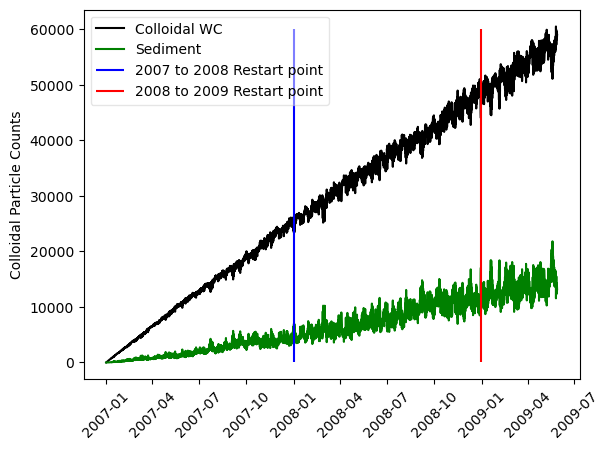

In [24]:
plt.plot(time_6h, all_system_timeseries, 'k', label = 'Colloidal WC')
plt.plot(time_6h, all_system_timeseries_sed, 'g', label = 'Sediment')
plt.vlines(x = xx, ymin = 0, ymax = 60000, color = 'b', label = '2007 to 2008 Restart point')
plt.vlines(x = xx1, ymin = 0, ymax = 60000, color = 'r', label = '2008 to 2009 Restart point')
plt.legend(loc = 'upper left', framealpha = .5)
plt.ylabel('Colloidal Particle Counts')
plt.xticks(rotation=45)

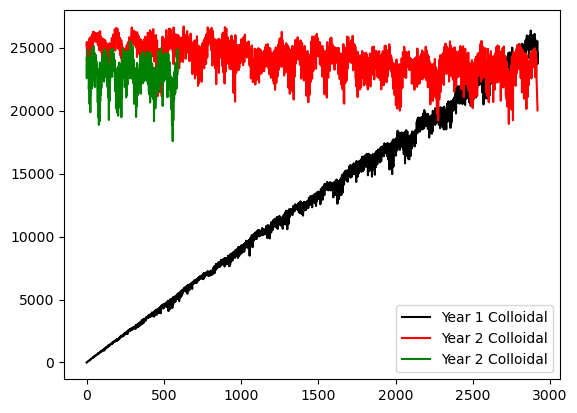

In [25]:
plt.plot(tseries_all_y1, 'k', label = 'Year 1 Colloidal')
plt.plot(tseries_all_y2, 'r', label = 'Year 2 Colloidal')
plt.plot(tseries_all_y3, 'g', label = 'Year 2 Colloidal')
plt.legend()

Text(0, 0.5, 'Particle Counts')

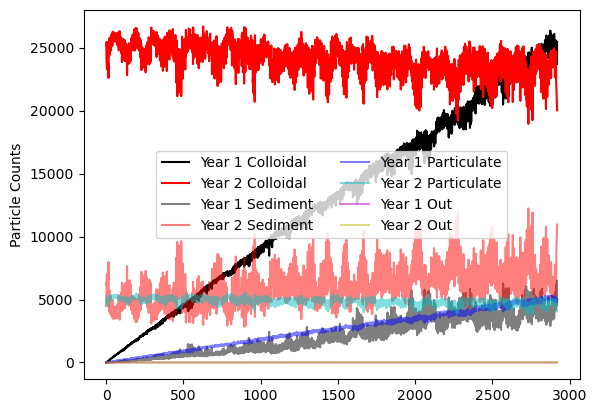

In [26]:
plt.plot(tseries_all_y1, 'k', label = 'Year 1 Colloidal')
plt.plot(tseries_all_y2, 'r', label = 'Year 2 Colloidal')
#
plt.plot(tseries_all_y1_sed, 'k', alpha = .5, label = 'Year 1 Sediment')
plt.plot(tseries_all_y2_sed,'r', alpha = .5, label = 'Year 2 Sediment')
#
plt.plot(tseries_all_y1_par, 'b', alpha = .5, label = 'Year 1 Particulate')
plt.plot(tseries_all_y2_par,'c', alpha = .5, label = 'Year 2 Particulate')
#
plt.plot(tseries_all_y1_out, 'm', alpha = .5, label = 'Year 1 Out')
plt.plot(tseries_all_y2_out,'y', alpha = .5, label = 'Year 2 Out')
#
plt.legend(ncol = 2, loc = 'center')
plt.ylabel('Particle Counts')